In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pycontrails import Fleet
from matplotlib.colors import TwoSlopeNorm

In [2]:
dff = pd.read_parquet("../data/filed_trajectories_EAGWP100.parquet")
fleetf = Fleet(data=dff)
print(f"Fleet contains {fleetf.n_flights} flights")

dfo = pd.read_parquet("../data/optimised_trajectories_EAGWP100.parquet")
fleeto = Fleet(data=dfo)
print(f"Fleet contains {fleeto.n_flights} flights")

Fleet contains 4112 flights
Fleet contains 4112 flights


In [3]:
from cane.utils import mask_by_marker

mask_by_marker(fleetf, ["nox", "NOx", "O3", "CH4"])
mask_by_marker(fleeto, ["nox", "NOx", "O3", "CH4"])

dff = fleetf.dataframe
dfo = fleeto.dataframe

# fleetf.dataframe[["flight_id", "waypoint", "pressure", "is_excluded", "nox"]]
# fleeto.dataframe[["flight_id", "waypoint", "pressure", "is_excluded", "nox"]]

Marked rows filtered out for nox
Marked rows filtered out for NOx
Marked rows filtered out for O3
Marked rows filtered out for CH4
Marked rows filtered out for nox
Marked rows filtered out for NOx
Marked rows filtered out for O3
Marked rows filtered out for CH4


In [4]:
from cane.utils import mask_by_validity_range

bounds = [150, 350]
mask_by_validity_range(fleetf, ["nox", "NOx", "O3", "CH4"], bounds)
mask_by_validity_range(fleeto, ["nox", "NOx", "O3", "CH4"], bounds)

dff = fleetf.dataframe
dfo = fleeto.dataframe

Bounds of [150, 350] in place for nox
Bounds of [150, 350] in place for NOx
Bounds of [150, 350] in place for O3
Bounds of [150, 350] in place for CH4
Bounds of [150, 350] in place for nox
Bounds of [150, 350] in place for NOx
Bounds of [150, 350] in place for O3
Bounds of [150, 350] in place for CH4


In [5]:
# nox_sum = dfo.groupby("flight_id").nox.sum()
# fids = list(nox_sum[nox_sum == 0].index)
# dff = dff.query("flight_id not in @fids")
# dfo = dfo.query("flight_id not in @fids")
# print(dff.flight_id.nunique())

In [6]:
# cruise_only = True
#
# if cruise_only:
#     dff = dff[(dff["air_pressure"] >= bounds[0] * 100) & (dff["air_pressure"] <= bounds[1] * 100)]
#     dfo = dfo[(dfo["air_pressure"] >= bounds[0] * 100) & (dfo["air_pressure"] <= bounds[1] * 100)]

In [7]:
from cane.labels import friendly_days, friendly_firs

In [8]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from cane.airspaces.borealis import borealis_airspaces_piontek2025


def prepare_heatmap(df, col, apm=None):
    day_fir = df.groupby(["day", "fir"]).agg({
        col: "sum",
    }).reset_index()

    # how to treat the APModel
    if apm is None or apm == "BADA3":
        day_fir = day_fir.groupby(["day", "fir"])[col].agg(["mean"]).reset_index().rename(
            columns={"mean": f"{col}_mean"})
        day_fir[f"{col}_mean"] = day_fir[f"{col}_mean"].fillna(0)
        matrix = day_fir.pivot(index="day", columns="fir", values=f"{col}_mean")
    else: # TODO
        day_fir = day_fir.query("APModel == @apm").reset_index()
        matrix = day_fir.pivot(index="day", columns="fir", values=col)
    return matrix[borealis_airspaces_piontek2025]

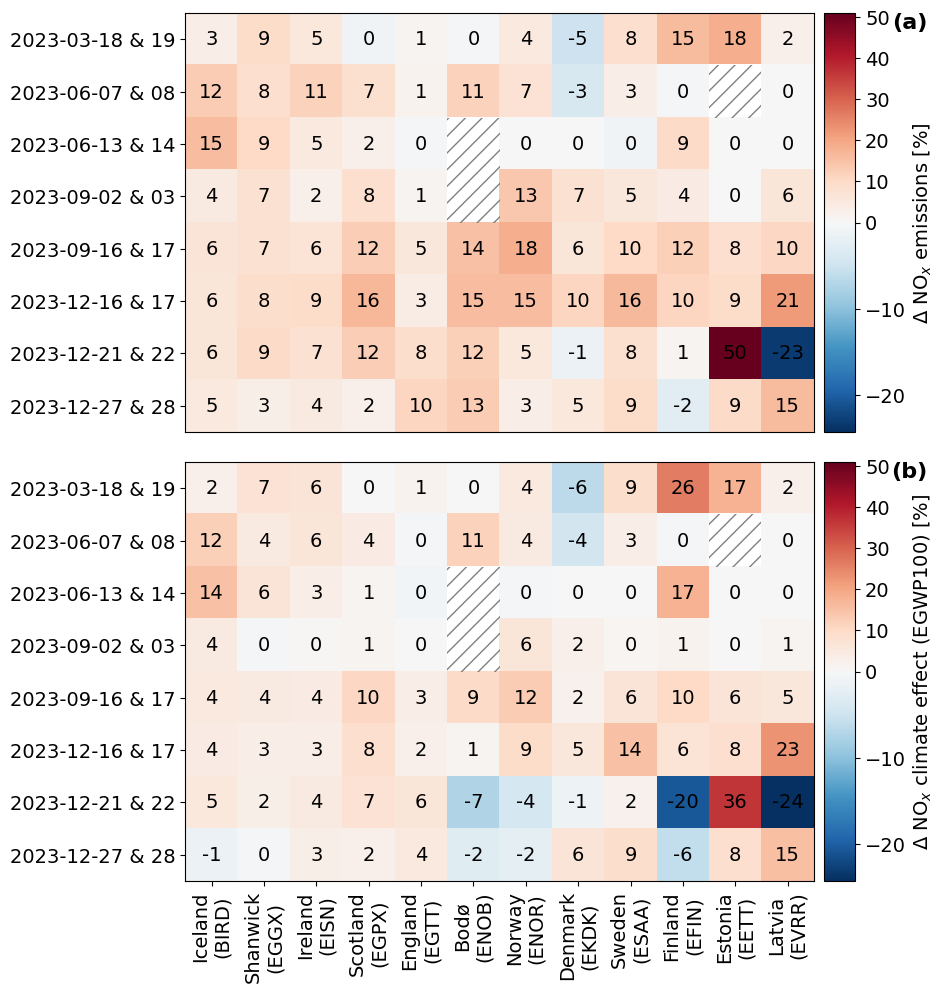

In [9]:
# combined heatmap
from matplotlib.colors import TwoSlopeNorm

from cane.utils import set_font_size

set_font_size(14)

def plot_heatmap_combined(m1, m2):
    vmin = min(np.nanmin(m1), np.nanmin(m2))
    vmax = max(np.nanmax(m1), np.nanmax(m2))
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), sharex=True, constrained_layout=True)
    fig.set_constrained_layout_pads(h_pad=0.15)

    labels = [
        r"$\Delta \ \text{NO}_x$ emissions [%]",
        r"$\Delta \ \text{NO}_x$ climate effect (EGWP100) [%]"
    ]

    ticks = [
        [-25, -20, -10, 0, 10, 20, 30, 40, 50],
        [-25, -20, -10, 0, 10, 20, 30, 40, 50],
    ]

    for i, matrix in enumerate([m1, m2]):
        cax = ax[i].matshow(matrix, cmap='RdBu_r', norm=norm)

        # Hatch NaN cells
        for (k, j), val in np.ndenumerate(matrix):
            if np.isnan(val):
                ax[i].add_patch(
                    plt.Rectangle((j - 0.5, k - 0.5), 1, 1, facecolor='none', hatch='//', edgecolor='gray', linewidth=0)
                )
            else:
                ax[i].text(j, k, f"{int(val)}", ha='center', va='center', color='black', fontsize=14)

        divider = make_axes_locatable(ax[i])
        cbar_ax = divider.append_axes("right", size="5%", pad=0.1)
        fig.colorbar(cax, cax=cbar_ax, label=labels[i], ticks=ticks[i])

        ax[i].set_yticks(range(len(matrix.index)))
        ax[i].set_yticklabels(friendly_days)
        ax[i].yaxis.set_ticks_position("left")

    ax[0].tick_params(bottom=False, top=False)
    ax[1].xaxis.set_ticks_position("bottom")
    ax[1].set_xticks(range(len(m2.columns)))
    # ax[1].set_xticklabels([f"{fir[:4]}" for fir in m2.columns], rotation=45, ha="right")
    ax[1].set_xticklabels([f"{friendly_firs[fir[:4]]}\n({fir[:4]})" for fir in matrix.columns], rotation=90,
                          fontsize=14)
    ax[0].grid(False)
    ax[1].grid(False)

    ax[0].text(
        1.18, 1, "(a)", zorder=100,
        transform=ax[0].transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="right"
    )

    ax[1].text(
        1.18, 1, "(b)",
        transform=ax[1].transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="right"
    )


c = "nox"
m_nox = (
        (prepare_heatmap(dfo, c, "BADA3")
         - prepare_heatmap(dff, c, "BADA3")) /
        prepare_heatmap(dff, c, "BADA3") * 100
)

c = "NOx"
m_co2eq_nox = (
        (prepare_heatmap(dfo, c, "BADA3")
         - prepare_heatmap(dff, c, "BADA3")) /
        prepare_heatmap(dff, c, "BADA3") * 100
)
plot_heatmap_combined(m_nox, m_co2eq_nox)
# plt.savefig(f"./figures/fig05_{bounds}_cruise.png", dpi=300, bbox_inches="tight")

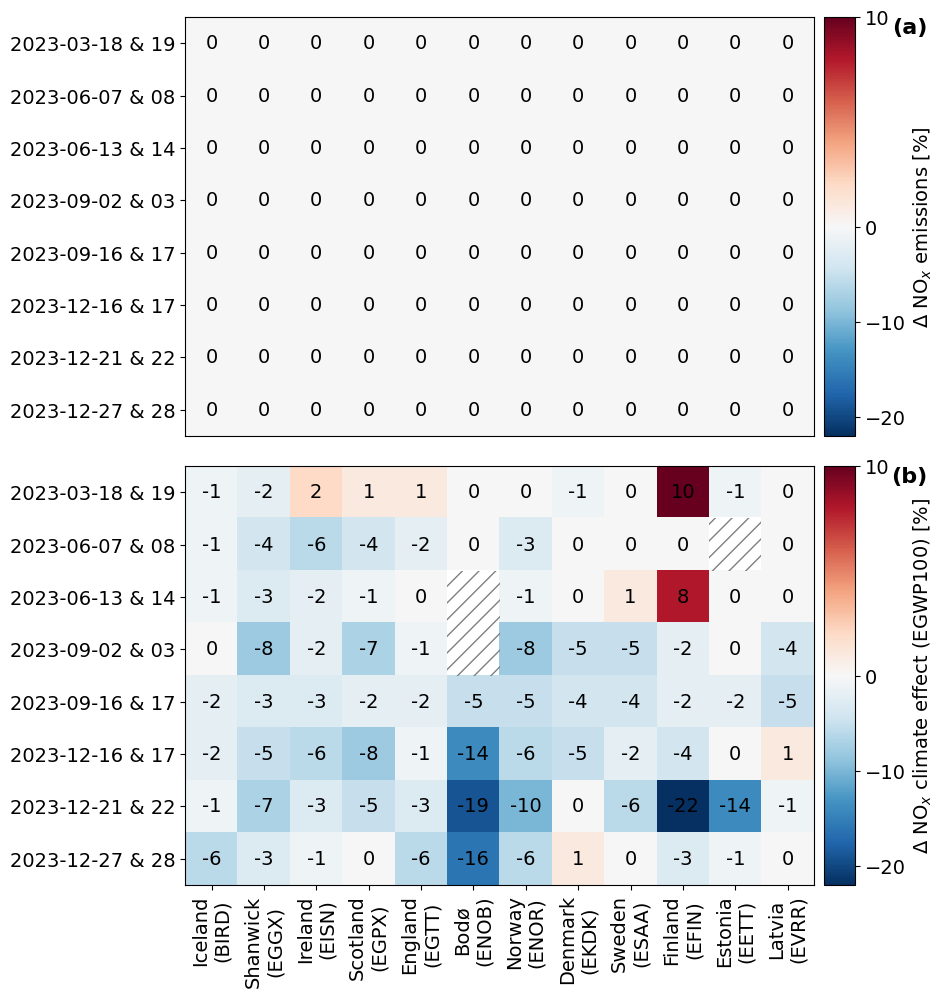

In [10]:
empty_matrix = m_nox.copy()
empty_matrix.loc[:, :] = 0

plot_heatmap_combined(empty_matrix, round(m_co2eq_nox - m_nox, 0))

In [11]:
print(round(prepare_heatmap(dff, "nox", "BADA3")["BIRD"].iloc[0]), "kg nox before")
print(round(prepare_heatmap(dfo, "nox", "BADA3")["BIRD"].iloc[0]), "kg nox after")
print("+45 kg NOx")
print("---")

print(round(prepare_heatmap(dff, "NOx", "BADA3")["BIRD"].iloc[0]), "kg CO2e before")
print(round(prepare_heatmap(dfo, "NOx", "BADA3")["BIRD"].iloc[0]), "kg CO2e after")
print("+2138 kg CO2e")

print("---")
print(round(2138 / 45), "kg CO2e per kg NOx")

1324 kg nox before
1369 kg nox after
+45 kg NOx
---
150065 kg CO2e before
154228 kg CO2e after
+2138 kg CO2e
---
48 kg CO2e per kg NOx


In [12]:
# print((prepare_heatmap(dfo, "NOx", "BADA3") - prepare_heatmap(dff, "NOx", "BADA3"))["BIRD"].iloc[0])
# print((prepare_heatmap(dfo, "nox", "BADA3") - prepare_heatmap(dff, "nox", "BADA3"))["BIRD"].iloc[0])
#
# 2138.294804756035 / 45.59705360256862

In [13]:
df1 = prepare_heatmap(dfo, "nox", "BADA3") - prepare_heatmap(dff, "nox", "BADA3")
df2 = prepare_heatmap(dfo, "NOx", "BADA3") - prepare_heatmap(dff, "NOx", "BADA3")

mask = np.sign(df1) != np.sign(df2)

In [14]:
np_map = np.clip(np.sign(df1) - np.sign(df2), -1, 1)

In [15]:
print(dff.NOx.sum() / dff.nox.sum())
print(dfo.NOx.sum() / dfo.nox.sum())

150.69558872186397
148.65777366015664


In [16]:
(dfo.NOx.sum() - dff.NOx.sum()) / (dfo.nox.sum() - dff.nox.sum())  # average: + 35kg CO2e per additional kg NOx

np.float64(67.75299744998264)

1 ... increased emissions, but decreased (sign change!) climate effect
-1, decreased emissions, but increased climate effect


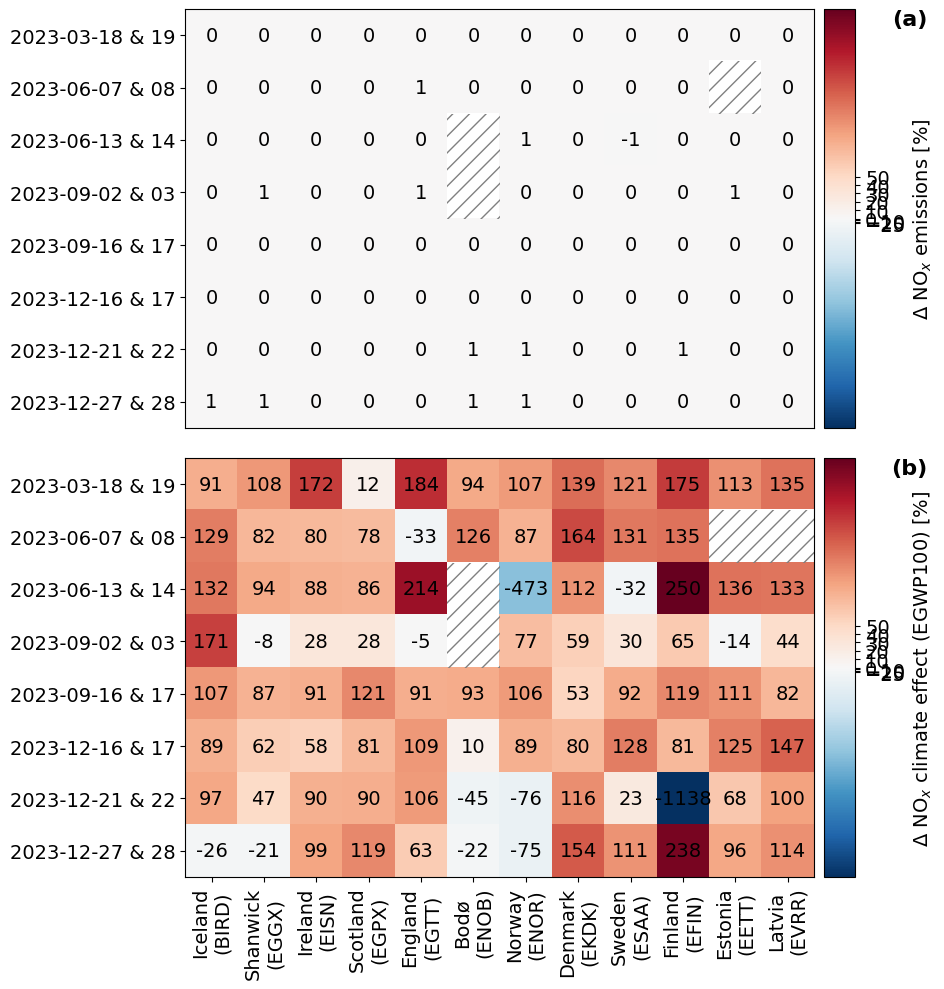

In [17]:
m_new = (prepare_heatmap(dfo, "NOx", "BADA3") - prepare_heatmap(dff, "NOx", "BADA3")) / (
        prepare_heatmap(dfo, "nox", "BADA3") - prepare_heatmap(dff, "nox", "BADA3"))

plot_heatmap_combined(np_map, m_new)
print("1 ... increased emissions, but decreased (sign change!) climate effect")
print("-1, decreased emissions, but increased climate effect")

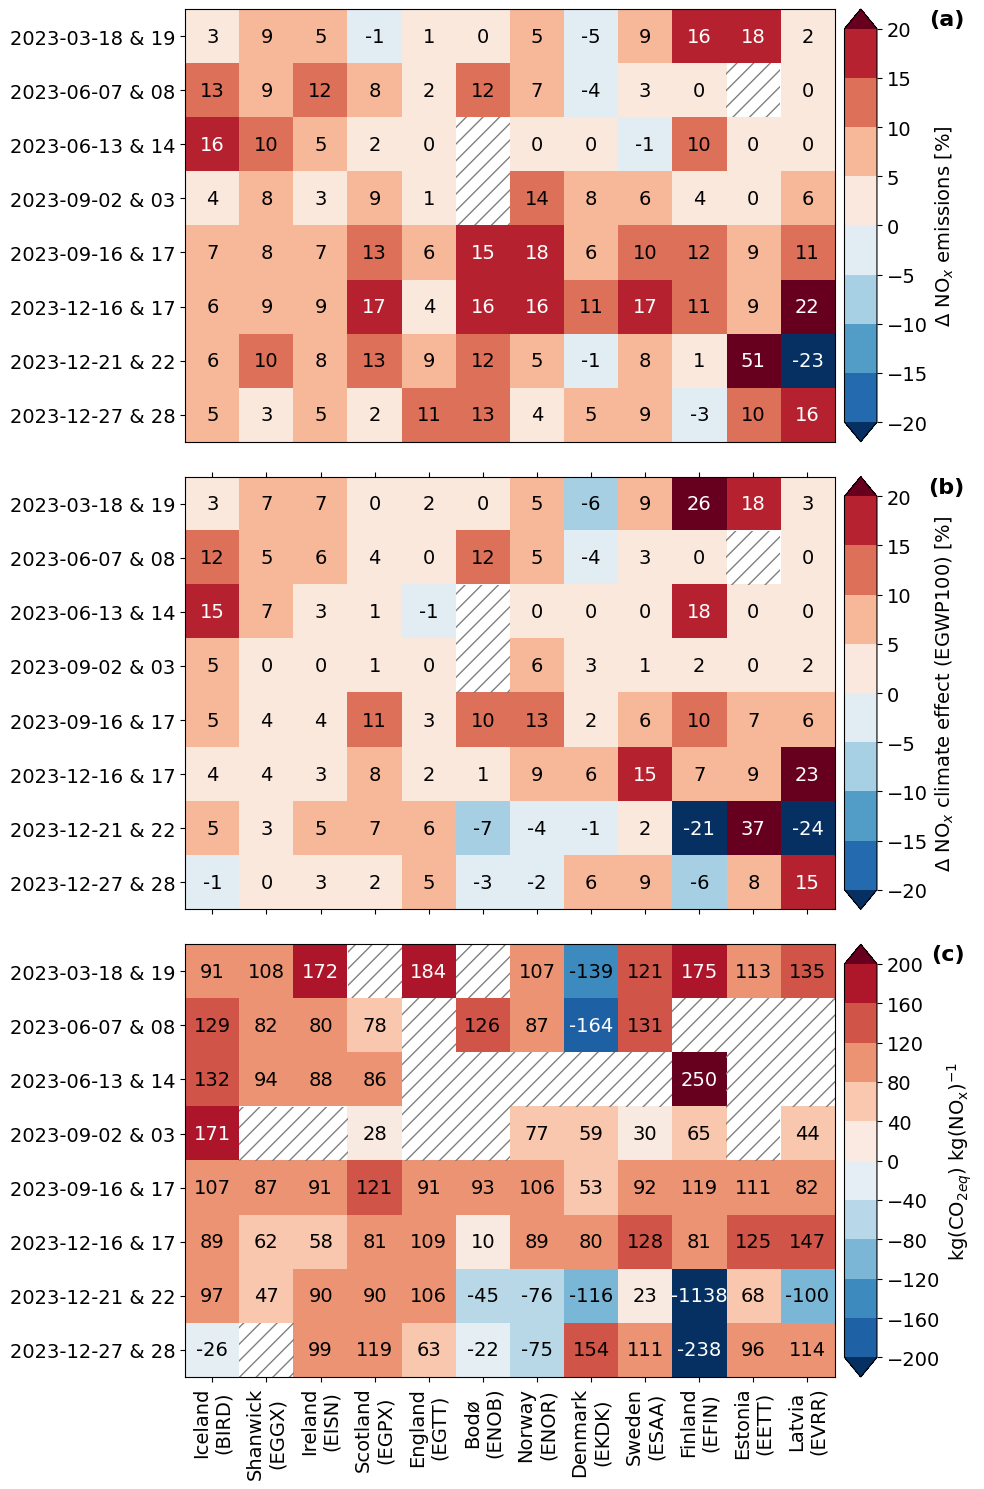

In [23]:
def plot_three_heatmaps(m1, m2, m3):
    import matplotlib.colors as mcolors

    # --- Colorbar configs ---
    # Rows 1 & 2: symmetric ±20, discrete steps
    bounds_12 = np.arange(-20, 21, 5)  # -20, -15, ..., 15, 20  (9 boundaries → 8 bins)
    # bounds_12 = np.array([-20, -15, -10, -5, -1, 1, 5, 10, 15, 20])
    norm_12 = mcolors.BoundaryNorm(boundaries=bounds_12, ncolors=256, extend='both')

    # Row 3: symmetric ±100, discrete steps
    bounds_3 = np.arange(-200, 201, 40)  # -100, -80, ..., 80, 100  (11 boundaries → 10 bins)
    norm_3 = mcolors.BoundaryNorm(boundaries=bounds_3, ncolors=256, extend='both')

    norms = [norm_12, norm_12, norm_3]
    bounds = [bounds_12, bounds_12, bounds_3]

    fig, ax = plt.subplots(3, 1, figsize=(10, 15), sharex=True, constrained_layout=True)
    fig.set_constrained_layout_pads(h_pad=0.15)

    labels = [
        r"$\Delta \ \text{NO}_x$ emissions [%]",
        r"$\Delta \ \text{NO}_x$ climate effect (EGWP100) [%]",
        r"kg(CO$_{2eq}$) kg(NO$_\text{x}$)$^{-1}$"
    ]

    for i, matrix in enumerate([m1, m2, m3]):
        cax = ax[i].matshow(matrix, cmap='RdBu_r', norm=norms[i])

        # Hatch NaN cells
        for (k, j), val in np.ndenumerate(matrix):
            if np.isnan(val):
                ax[i].add_patch(
                    plt.Rectangle(
                        (j - 0.5, k - 0.5), 1, 1,
                        facecolor='none', hatch='//', edgecolor='gray', linewidth=0
                    )
                )
            else:
                # if val == 0:
                #     ax[i].add_patch(
                #         plt.Rectangle(
                #             (j - 0.5, k - 0.5), 1, 1,
                #             facecolor='none', hatch='..', edgecolor='gray', linewidth=0
                #         )
                #     )
                # Pick white text on dark cells, black on light cells
                norm_val = norms[i](val)
                rgba = plt.cm.RdBu_r(norm_val)
                luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
                text_color = 'white' if luminance < 0.45 else 'black'

                ax[i].text(
                    j, k, f"{int(val)}",
                    ha='center', va='center', color=text_color, fontsize=14
                )

        divider = make_axes_locatable(ax[i])
        cbar_ax = divider.append_axes("right", size="5%", pad=0.1)
        cb = fig.colorbar(
            cax,
            cax=cbar_ax,
            label=labels[i],
            ticks=bounds[i],  # tick at every boundary
            extend='both',  # draw the triangles
            spacing='uniform',  # equal-width discrete segments
        )
        # cb.ax.tick_params(labelsize=9)

        ax[i].set_yticks(range(len(matrix.index)))
        ax[i].set_yticklabels(friendly_days)
        ax[i].yaxis.set_ticks_position("left")

    ax[0].tick_params(bottom=False, top=False)
    ax[2].xaxis.set_ticks_position("bottom")
    ax[2].set_xticks(range(len(m2.columns)))
    ax[2].set_xticklabels([f"{friendly_firs[fir[:4]]}\n({fir[:4]})" for fir in matrix.columns], rotation=90,
                          fontsize=14)
    ax[0].grid(False)
    ax[1].grid(False)

    ax[0].text(
        1.2, 1, "(a)", zorder=100,
        transform=ax[0].transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="right"
    )

    ax[1].text(
        1.2, 1, "(b)",
        transform=ax[1].transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="right"
    )

    ax[2].text(
        1.2, 1, "(c)",
        transform=ax[2].transAxes,
        fontsize=16, fontweight="bold",
        va="top", ha="right"
    )


from cane.utils import set_font_size

set_font_size(14)

m_nox = (
        (prepare_heatmap(dfo, "nox", "BADA3")
         - prepare_heatmap(dff, "nox", "BADA3")) /
        prepare_heatmap(dff, "nox", "BADA3") * 100
)

m_co2eq_nox = (
        (prepare_heatmap(dfo, "NOx", "BADA3")
         - prepare_heatmap(dff, "NOx", "BADA3")) /
        prepare_heatmap(dff, "NOx", "BADA3") * 100
)

m_new = (prepare_heatmap(dfo, "NOx", "BADA3") - prepare_heatmap(dff, "NOx", "BADA3")) / (
        abs(prepare_heatmap(dfo, "nox", "BADA3") - prepare_heatmap(dff, "nox", "BADA3")))

plot_three_heatmaps(round(m_nox), round(m_co2eq_nox), m_new[(round(m_nox) != 0) & (round(m_co2eq_nox) != 0)])
plt.savefig(f"./figures/fig05.png", dpi=300, bbox_inches="tight")